Epoch 1/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.8220 - val_loss: 0.3592
Epoch 2/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3434 - val_loss: 0.2495
Epoch 3/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2428 - val_loss: 0.1863
Epoch 4/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1873 - val_loss: 0.1507
Epoch 5/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1610 - val_loss: 0.1302
Epoch 6/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1496 - val_loss: 0.1187
Epoch 7/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1334 - val_loss: 0.1093
Epoch 8/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1243 - val_loss: 0.1022
Epoch 9/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1152 - val_loss: 0.0949
Epoch 10/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1096 - val_loss: 0.0887
Epoch 11/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1037 - val_loss: 0.0834
Epoch 12/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2819
Epoch 3/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1571
Epoch 4/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1126
Epoch 5/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0891
Epoch 6/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0797
Epoch 7/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0710
Epoch 8/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0701
Epoch 9/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0660
Epoch 10/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0638
Epoch 11/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0604
Epoch 12/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0543
Epoch 13/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0534
Epoch 14/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0496
Epoch 15/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0479
Epoch 16/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0484

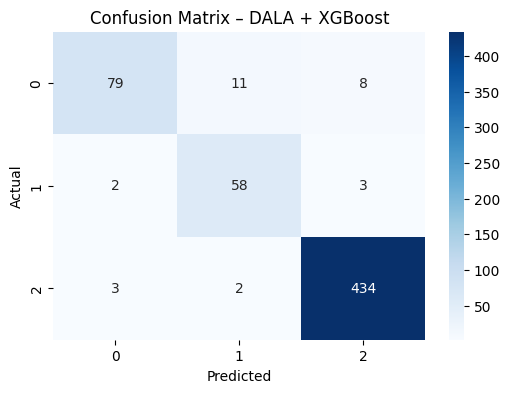

In [ ]:
# =====================================================
# DALA – XGBoost: Fetal–Maternal Risk Alignment Model
# =====================================================

# -------------------------
# STEP 1: Imports
# -------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import euclidean_distances

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import xgboost as xgb


# -------------------------
# STEP 2: Load datasets
# -------------------------
fetal_df = pd.read_csv("fetal_health_balanced.csv")
maternal_df = pd.read_csv("synthetic_maternal_unlabeled_vae.csv")


# -------------------------
# STEP 3: Fetal data preprocessing
# -------------------------
X_fetal = fetal_df.drop(columns=["fetal_health"])
y_fetal = fetal_df["fetal_health"] - 1   # convert 1,2,3 → 0,1,2

scaler_fetal = StandardScaler()
X_fetal_scaled = scaler_fetal.fit_transform(X_fetal)


# -------------------------
# STEP 4: Maternal data preprocessing
# -------------------------
X_maternal = maternal_df.select_dtypes(include=[np.number]).dropna()

scaler_maternal = StandardScaler()
X_maternal_scaled = scaler_maternal.fit_transform(X_maternal)


# -------------------------
# STEP 5: Autoencoder function
# -------------------------
def build_autoencoder(input_dim, latent_dim=8, dropout_rate=0.01):
    inputs = Input(shape=(input_dim,))

    x = Dense(32, activation="relu")(inputs)
    x = Dropout(dropout_rate)(x)
    latent = Dense(latent_dim, activation="relu")(x)

    x = Dense(32, activation="relu")(latent)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(input_dim, activation="linear")(x)

    autoencoder = Model(inputs, outputs)
    encoder = Model(inputs, latent)

    autoencoder.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return autoencoder, encoder


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


# -------------------------
# STEP 6: Train fetal autoencoder
# -------------------------
fetal_autoencoder, fetal_encoder = build_autoencoder(X_fetal_scaled.shape[1])

Xf_train, Xf_val = train_test_split(
    X_fetal_scaled, test_size=0.2, random_state=42
)

fetal_autoencoder.fit(
    Xf_train, Xf_train,
    validation_data=(Xf_val, Xf_val),
    epochs=60,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Z_fetal = fetal_encoder.predict(X_fetal_scaled)


# -------------------------
# STEP 7: KMeans on fetal latent space
# -------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(Z_fetal)

fetal_centroids = kmeans.cluster_centers_


# -------------------------
# STEP 8: Train maternal autoencoder
# -------------------------
maternal_autoencoder, maternal_encoder = build_autoencoder(
    X_maternal_scaled.shape[1]
)

maternal_autoencoder.fit(
    X_maternal_scaled, X_maternal_scaled,
    epochs=60,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Z_maternal = maternal_encoder.predict(X_maternal_scaled)


# -------------------------
# STEP 9: Pseudo-label transfer
# -------------------------
distance_matrix = euclidean_distances(Z_maternal, fetal_centroids)
maternal_pseudo_labels = np.argmin(distance_matrix, axis=1)


# -------------------------
# STEP 10: XGBoost training
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    Z_maternal,
    maternal_pseudo_labels,
    test_size=0.2,
    random_state=42
)

xgb_model = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train)


# -------------------------
# STEP 11: Evaluation
# -------------------------
y_pred = xgb_model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


# -------------------------
# STEP 12: Confusion Matrix
# -------------------------
conf_matrix = pd.crosstab(
    y_test,
    y_pred,
    rownames=["Actual"],
    colnames=["Predicted"]
)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix – DALA + XGBoost")
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import lime
import lime.lime_tabular


ModuleNotFoundError: No module named 'lime'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=85c0ea713a66d9c6776e1a73c06a61dea31dadf156d53a9d5bb0fc4540b9eab0
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


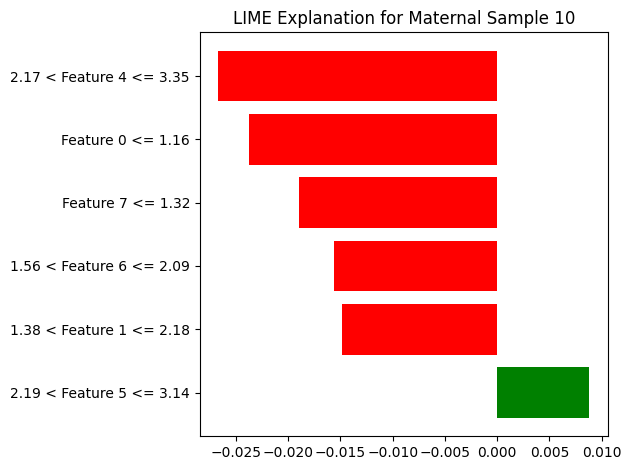

In [ ]:
# ✅ Install LIME (only once)
!pip install lime

# ✅ Imports
import numpy as np
import matplotlib.pyplot as plt
import lime
import lime.lime_tabular

# ✅ Initialize the LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(Z_maternal),  # Your encoded maternal features
    feature_names=[f"Feature {i}" for i in range(Z_maternal.shape[1])],
    class_names=['Low', 'Moderate', 'High'],  # Change labels if needed
    mode='classification'
)

# ✅ Pick an instance to explain
instance_index = 10  # Change index as needed
exp = explainer.explain_instance(
    data_row=Z_maternal[instance_index],
    predict_fn=xgb_model.predict_proba,
    num_features=6  # Show top 6 features
)

# ✅ Plot the explanation
fig = exp.as_pyplot_figure()
plt.title(f"LIME Explanation for Maternal Sample {instance_index}")
plt.tight_layout()
plt.show()


In [ ]:
pip install lime
